# **1 - Importing Libraries**

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

# **2 - Load and Preprocess MNIST**

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


## 2.1 - Visualizing MINST Samples before training

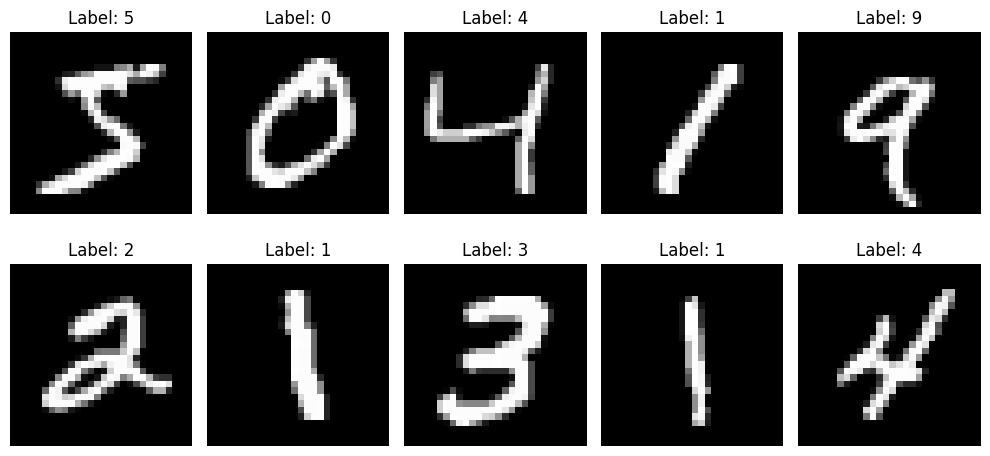

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# First img shape + label --> 5
image, label = train_dataset[0]

print("Shape:", image.shape)
print("Label:", label)

Shape: torch.Size([1, 28, 28])
Label: 5


# **3 - Create Train / Validation Split + DataLoaders**

In [13]:
# Create Train / Validation Split

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 54000
Validation: 6000
Test: 10000


In [14]:
# DataLoaders

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


# **4 - Device Setup**

In [15]:
device=torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


# **5 — Build Flexible MLP Class**

In [16]:
class FlexibleMLP(nn.Module):

    def __init__(
        self,
        hidden_layers,
        activation='relu',
        dropout=0,
        batch_norm=False
    ):

        super().__init__()

        layers=[]

        input_size=784


        for neurons in hidden_layers:

            layers.append(
                nn.Linear(
                    input_size,
                    neurons
                )
            )


            # Batch Normalization
            if batch_norm:
                layers.append(nn.BatchNorm1d(neurons))


            # Activation
            if activation=='relu':
                layers.append(nn.ReLU())

            elif activation=='sigmoid':
                layers.append(nn.Sigmoid())


            # Dropout
            if dropout>0:
                layers.append(
                    nn.Dropout(dropout)
                )


            input_size=neurons


        layers.append(nn.Linear(input_size,10) )


        self.network=nn.Sequential(
            nn.Flatten(),
            *layers
        )


    def forward(self,x):

        return self.network(x)

In [17]:
test_model=FlexibleMLP(
    [256,128],
    activation='relu',
    dropout=0.3,
    batch_norm=True
)

print(test_model)

FlexibleMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


# **6 — Create Reusable Training Function**

In [18]:
def train_model(model, epochs=10, lr=0.001):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses=[]
    val_losses=[]

    train_accs=[]
    val_accs=[]


    for epoch in range(epochs):

        # ================= TRAIN =================

        model.train()

        running_loss=0
        correct=0
        total=0


        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)


            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _,predicted=torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()



        train_loss=running_loss/len(train_loader)

        train_acc=100*correct/total



        # ================= VALIDATION =================

        model.eval()

        running_loss=0
        correct=0
        total=0


        with torch.no_grad():

            for images,labels in val_loader:

                images=images.to(device)
                labels=labels.to(device)

                outputs=model(images)

                loss=criterion(outputs,labels)

                running_loss += loss.item()

                _,predicted=torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted==labels).sum().item()


        val_loss=running_loss/len(val_loader)

        val_acc=100*correct/total


        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)


        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss:{train_loss:.4f} "
            f"| Train Acc:{train_acc:.2f}% "
            f"| Val Loss:{val_loss:.4f} "
            f"| Val Acc:{val_acc:.2f}%"
        )


    return (
        model,
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

# **7 — Test Function**

In [19]:
def evaluate(model):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    test_loss=0

    correct=0
    total=0


    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)
            labels=labels.to(device)


            outputs=model(images)

            loss=criterion(outputs,labels)
            test_loss += loss.item()

            _,predicted=torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()



    accuracy=100*correct/total

    test_loss=test_loss/len(test_loader)


    return accuracy,test_loss

# **8 — Main Experiment Function**

In [20]:
results=[]


def run_experiment(
    hidden_layers,
    activation,
    lr,
    title,
    dropout=0,
    batch_norm=False
):


    print("="*55)

    print(title)

    print(
        f"Neurons:{hidden_layers}"
        f" | Activation:{activation}"
        f" | LR:{lr}"
    )

    print("="*55)


    model=FlexibleMLP(
        hidden_layers,
        activation,
        dropout,
        batch_norm
    )


    model, train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    epochs=10,
    lr=lr
    )


    test_acc,test_loss = evaluate(model)


    results.append({
        'Experiment':title,
        'Neurons':str(hidden_layers),
        'Activation':activation,
        'LR':lr,
        'Accuracy':round(test_acc, 2),
        'Loss':round(test_loss, 4)
    })

    print()
    print(f"Test Accuracy:"f"{test_acc:.2f}%")
    print(f"Test Loss:"f"{test_loss:.4f}")


    return (
        model,
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

# **Experiment 1 — Baseline ReLU**

In [21]:
exp1 = run_experiment(
    hidden_layers=[128,64],
    activation='relu',
    lr=0.001,
    title='Exp1 Baseline ReLU'
)

Exp1 Baseline ReLU
Neurons:[128, 64] | Activation:relu | LR:0.001
Epoch [1/10] | Train Loss:0.4217 | Train Acc:87.47% | Val Loss:0.2526 | Val Acc:92.28%
Epoch [2/10] | Train Loss:0.2041 | Train Acc:93.78% | Val Loss:0.1760 | Val Acc:94.63%
Epoch [3/10] | Train Loss:0.1522 | Train Acc:95.37% | Val Loss:0.1455 | Val Acc:95.75%
Epoch [4/10] | Train Loss:0.1190 | Train Acc:96.34% | Val Loss:0.1205 | Val Acc:96.40%
Epoch [5/10] | Train Loss:0.1022 | Train Acc:96.82% | Val Loss:0.1345 | Val Acc:96.07%
Epoch [6/10] | Train Loss:0.0886 | Train Acc:97.19% | Val Loss:0.1084 | Val Acc:96.73%
Epoch [7/10] | Train Loss:0.0815 | Train Acc:97.35% | Val Loss:0.1180 | Val Acc:96.13%
Epoch [8/10] | Train Loss:0.0703 | Train Acc:97.80% | Val Loss:0.1270 | Val Acc:96.42%
Epoch [9/10] | Train Loss:0.0654 | Train Acc:97.83% | Val Loss:0.1073 | Val Acc:96.70%
Epoch [10/10] | Train Loss:0.0597 | Train Acc:98.05% | Val Loss:0.0990 | Val Acc:97.05%

Test Accuracy:96.93%
Test Loss:0.0956


# **Experiment 2 — Sigmoid**

In [22]:
exp2 = run_experiment(
    hidden_layers=[128,64],
    activation='sigmoid',
    lr=0.001,
    title='Exp2 Sigmoid'
)

Exp2 Sigmoid
Neurons:[128, 64] | Activation:sigmoid | LR:0.001
Epoch [1/10] | Train Loss:0.6882 | Train Acc:82.41% | Val Loss:0.2859 | Val Acc:92.00%
Epoch [2/10] | Train Loss:0.2333 | Train Acc:93.36% | Val Loss:0.2004 | Val Acc:94.58%
Epoch [3/10] | Train Loss:0.1623 | Train Acc:95.32% | Val Loss:0.1543 | Val Acc:95.60%
Epoch [4/10] | Train Loss:0.1263 | Train Acc:96.35% | Val Loss:0.1441 | Val Acc:95.90%
Epoch [5/10] | Train Loss:0.1044 | Train Acc:96.89% | Val Loss:0.1219 | Val Acc:96.60%
Epoch [6/10] | Train Loss:0.0889 | Train Acc:97.38% | Val Loss:0.1130 | Val Acc:96.53%
Epoch [7/10] | Train Loss:0.0763 | Train Acc:97.74% | Val Loss:0.1062 | Val Acc:96.68%
Epoch [8/10] | Train Loss:0.0662 | Train Acc:98.06% | Val Loss:0.0977 | Val Acc:96.97%
Epoch [9/10] | Train Loss:0.0611 | Train Acc:98.13% | Val Loss:0.0944 | Val Acc:97.42%
Epoch [10/10] | Train Loss:0.0532 | Train Acc:98.43% | Val Loss:0.0987 | Val Acc:96.87%

Test Accuracy:97.16%
Test Loss:0.0882


# **Experiment 3 — Larger Network + Lower LR + Dropout + BatchNorm**
## Applying Some Enhancement Techniques

In [23]:
exp3 = run_experiment(
    hidden_layers=[256,128],
    activation='relu',
    lr=0.0005,
    title='Exp3 Large Net + Low LR + Dropout + BatchNorm',
    dropout=0.3,
    batch_norm=True
)

Exp3 Large Net + Low LR + Dropout + BatchNorm
Neurons:[256, 128] | Activation:relu | LR:0.0005
Epoch [1/10] | Train Loss:0.3807 | Train Acc:90.07% | Val Loss:0.1411 | Val Acc:95.83%
Epoch [2/10] | Train Loss:0.1718 | Train Acc:94.97% | Val Loss:0.1056 | Val Acc:96.92%
Epoch [3/10] | Train Loss:0.1365 | Train Acc:95.82% | Val Loss:0.0860 | Val Acc:97.42%
Epoch [4/10] | Train Loss:0.1157 | Train Acc:96.46% | Val Loss:0.0757 | Val Acc:97.62%
Epoch [5/10] | Train Loss:0.1008 | Train Acc:96.83% | Val Loss:0.0764 | Val Acc:97.63%
Epoch [6/10] | Train Loss:0.0893 | Train Acc:97.13% | Val Loss:0.0768 | Val Acc:97.75%
Epoch [7/10] | Train Loss:0.0813 | Train Acc:97.43% | Val Loss:0.0711 | Val Acc:97.75%
Epoch [8/10] | Train Loss:0.0785 | Train Acc:97.48% | Val Loss:0.0724 | Val Acc:97.75%
Epoch [9/10] | Train Loss:0.0689 | Train Acc:97.77% | Val Loss:0.0662 | Val Acc:98.10%
Epoch [10/10] | Train Loss:0.0676 | Train Acc:97.84% | Val Loss:0.0667 | Val Acc:98.08%

Test Accuracy:98.15%
Test Loss:0.

# **9 — Comparisons**

In [24]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Experiment,Neurons,Activation,LR,Accuracy,Loss
0,Exp1 Baseline ReLU,"[128, 64]",relu,0.0010,96.93,0.0956
1,Exp2 Sigmoid,"[128, 64]",sigmoid,0.0010,97.16,0.0882
2,Exp3 Large Net + Low LR + Dropout + BatchNorm,"[256, 128]",relu,0.0005,98.15,0.0626


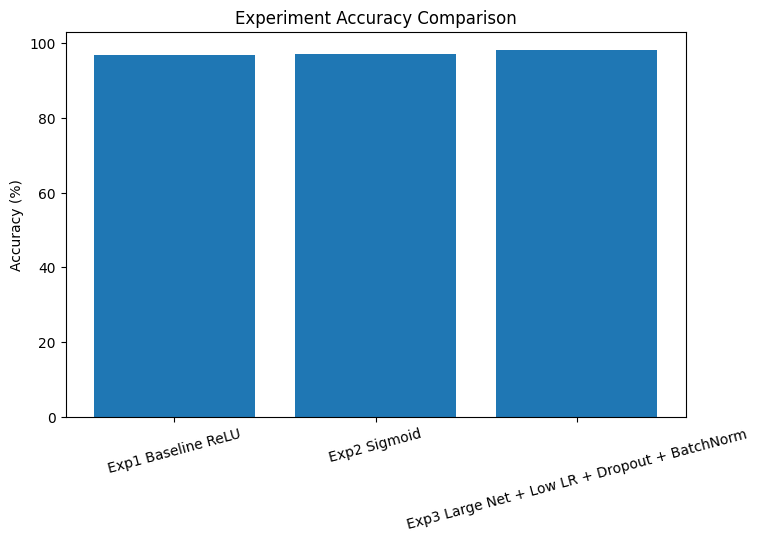

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Experiment'],
    results_df['Accuracy']
)

plt.ylabel("Accuracy (%)")
plt.title("Experiment Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

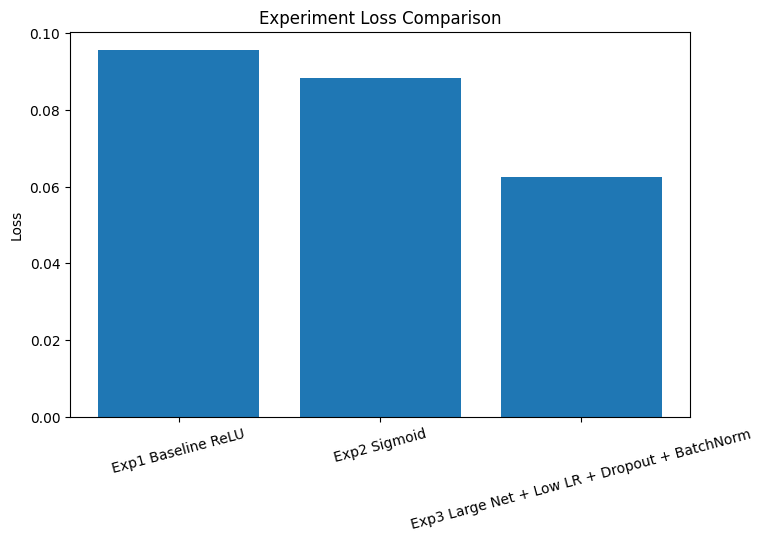

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Experiment'],
    results_df['Loss']
)

plt.ylabel("Loss")
plt.title("Experiment Loss Comparison")

plt.xticks(rotation=15)

plt.show()

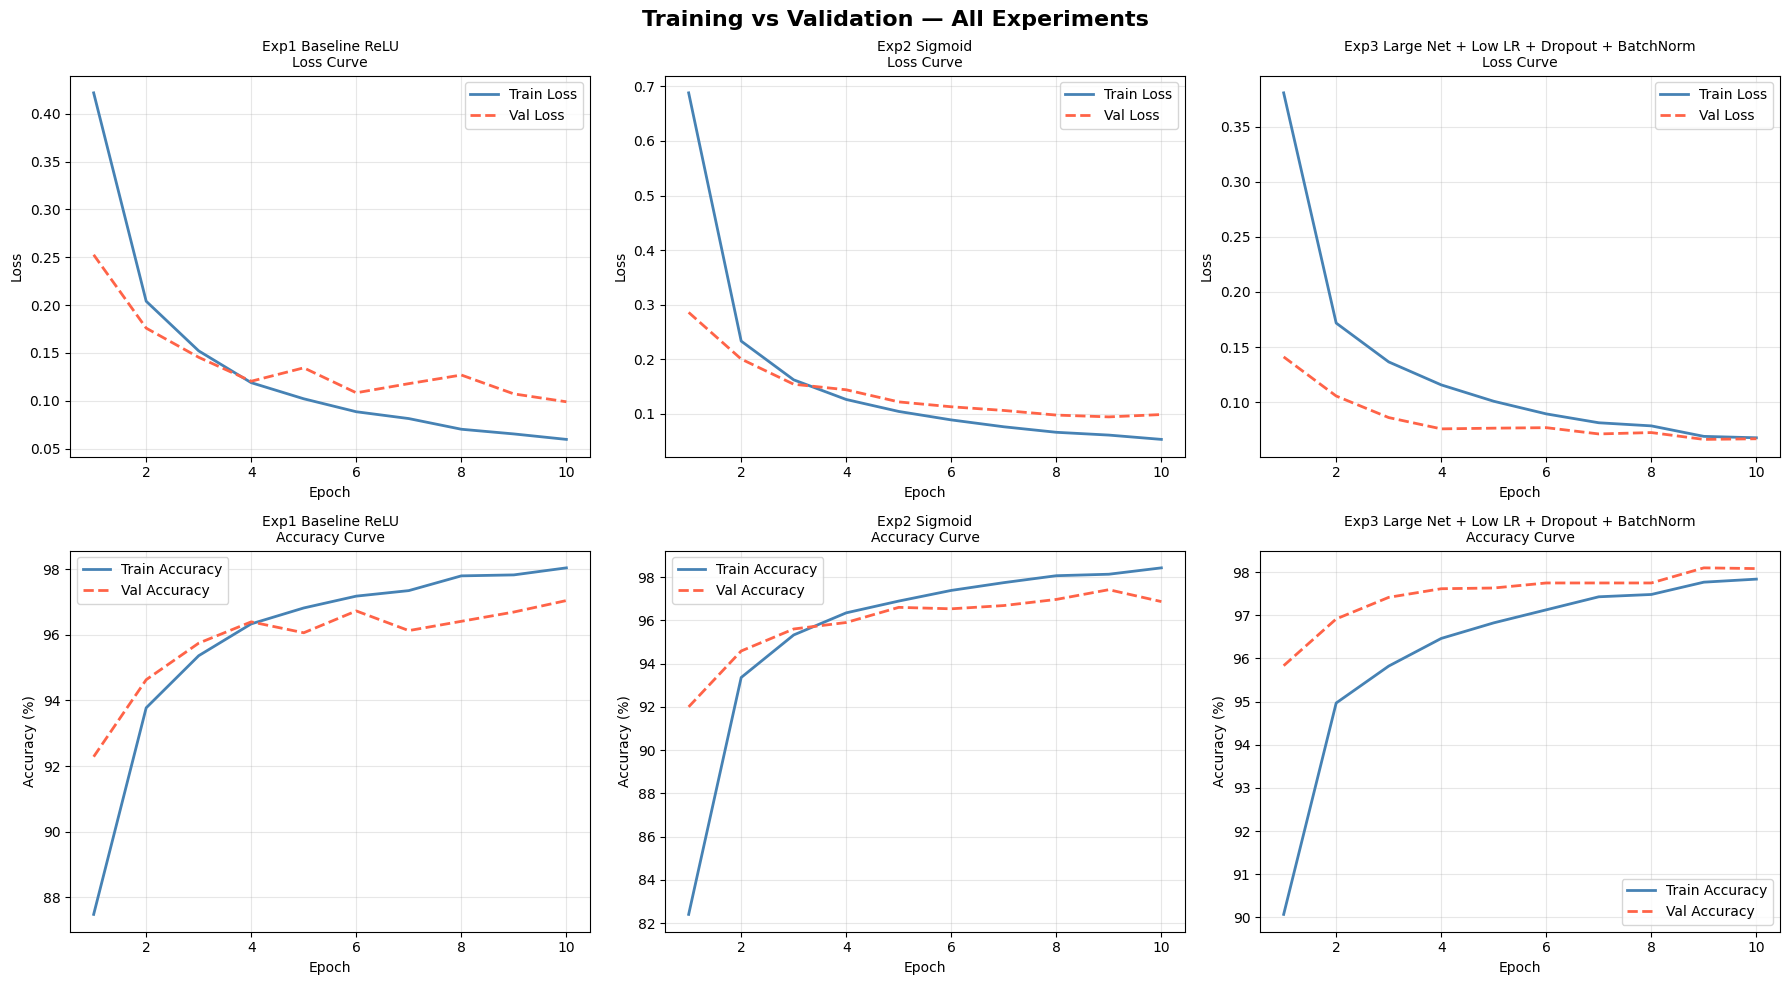

In [27]:
# **9 — Visualization: Loss & Accuracy Curves for All Experiments**

experiments = [
    ('Exp1 Baseline ReLU', exp1),
    ('Exp2 Sigmoid',       exp2),
    ('Exp3 Large Net + Low LR + Dropout + BatchNorm', exp3),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training vs Validation — All Experiments', fontsize=16, fontweight='bold')

for col, (title, exp_data) in enumerate(experiments):

    _, train_losses, val_losses, train_accs, val_accs = exp_data
    epochs = range(1, len(train_losses) + 1)

    # --- Loss Curve ---
    ax_loss = axes[0][col]
    ax_loss.plot(epochs, train_losses, label='Train Loss',      color='steelblue',  linewidth=2)
    ax_loss.plot(epochs, val_losses,   label='Val Loss',        color='tomato',     linewidth=2, linestyle='--')
    ax_loss.set_title(f'{title}\nLoss Curve', fontsize=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # --- Accuracy Curve ---
    ax_acc = axes[1][col]
    ax_acc.plot(epochs, train_accs, label='Train Accuracy',  color='steelblue',  linewidth=2)
    ax_acc.plot(epochs, val_accs,   label='Val Accuracy',    color='tomato',     linewidth=2, linestyle='--')
    ax_acc.set_title(f'{title}\nAccuracy Curve', fontsize=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **10 — The Best Model**

In [28]:
best = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print(best)

Experiment    Exp3 Large Net + Low LR + Dropout + BatchNorm
Neurons                                          [256, 128]
Activation                                             relu
LR                                                   0.0005
Accuracy                                              98.15
Loss                                                 0.0626
Name: 2, dtype: object
